# Block 6 — Scenario Comparison and the Barista Decision

**ODSC Tutorial: Spec-Driven Simulation Modeling**

Block 4 established that the baseline scenario produces a P90 wait around six and a half minutes during the morning rush — the actual customer-experience problem. Block 5 confirmed that the simulation faithfully implements the spec.

Now we use the validated simulation to answer the decision question that started the workshop:

> *Should the shop owner hire a third barista during the morning rush, or is there a cheaper way to fix the wait-time problem?*

We compare four scenarios across four metrics, and at the end, **you write the recommendation**.

**Run time:** about 30-45 seconds for all four scenarios at 50 replications each.

## Setup

Same imports as Block 4. We re-import the SimPy module here so this notebook can be run standalone.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
CODE_DIR = ROOT / "code"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import coffee_shop_des as sim

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Color map shared across all comparison plots
SCENARIO_COLORS = {
    "Baseline": "#6B7280",                 # neutral grey
    "A: Rush boost": "#3B6EA5",            # primary blue
    "B: All-day 3": "#8E44AD",             # purple
    "C: Process improvement": "#B85042",   # terracotta
}

print("SimPy module loaded. Scenarios available:")
for name, scn in sim.SCENARIOS.items():
    print(f"  {name:<26} ${scn.daily_cost:>4.0f}/day  —  {scn.description}")

SimPy module loaded. Scenarios available:
  Baseline                   $ 289/day  —  Current operations (2/2/1)
  A: Rush boost              $ 323/day  —  +1 barista during morning rush (3/2/1)
  B: All-day 3               $ 459/day  —  +1 barista every window (3/3/2)
  C: Process improvement     $ 289/day  —  15% faster service 7–9 AM (2/2/1)


## 1. Run all four scenarios

Each scenario gets 50 replications. The seeds are deterministic and identical across scenarios — the same simulated days are run under different staffing rules, so the differences we see are due to the staffing change, not random luck.

In [2]:
all_summaries = {}
all_customers = {}
all_traces = {}

t0 = time.time()
for name, scenario in sim.SCENARIOS.items():
    df_summary, df_customers, queue_trace = sim.run_scenario(scenario, n_replications=50)
    all_summaries[name] = df_summary
    all_customers[name] = df_customers
    all_traces[name] = queue_trace
    print(f"  {name:<26}  done  ({len(df_summary)} reps)")

print(f"\nAll four scenarios run in {time.time() - t0:.1f}s.")

  Baseline                    done  (50 reps)
  A: Rush boost               done  (50 reps)
  B: All-day 3                done  (50 reps)
  C: Process improvement      done  (50 reps)

All four scenarios run in 0.9s.


## 2. Side-by-side comparison

Four metrics, four scenarios, one table. Read horizontally — each row tells you how each scenario performs on that metric.

In [3]:
def headline_row(df: pd.DataFrame, name: str, scenario) -> dict:
    return {
        "scenario": name,
        "mean_wait_min": round(df["mean_wait"].mean(), 2),
        "p90_wait_min": round(df["p90_wait"].mean(), 2),
        "walkaway_rate_pct": round(df["walkaway_rate"].mean() * 100, 2),
        "morning_util": round(df["util_0_120"].mean(), 3),
        "mean_served_per_day": int(round(df["n_served"].mean())),
        "daily_cost_usd": int(scenario.daily_cost),
    }

comparison = pd.DataFrame([
    headline_row(all_summaries[name], name, scn)
    for name, scn in sim.SCENARIOS.items()
])
comparison.set_index("scenario", inplace=True)

# Add per-scenario cost delta vs baseline
baseline_cost = comparison.loc["Baseline", "daily_cost_usd"]
comparison["cost_delta_vs_baseline"] = comparison["daily_cost_usd"] - baseline_cost

print(comparison.to_string())

                        mean_wait_min  p90_wait_min  walkaway_rate_pct  morning_util  mean_served_per_day  daily_cost_usd  cost_delta_vs_baseline
scenario                                                                                                                                         
Baseline                         1.97          6.38               0.79         0.820                  149             289                       0
A: Rush boost                    1.03          3.50               0.00         0.563                  151             323                      34
B: All-day 3                     0.25          0.82               0.00         0.564                  152             459                     170
C: Process improvement           1.52          5.06               0.05         0.727                  152             289                       0


What jumps out:

- **Baseline** sits at the problem the workshop is solving — P90 wait around six and a half minutes, walkaways under one percent, \$289/day.
- **A: rush boost** cuts P90 by roughly half and drops walkaways to zero, for **+\$34/day**.
- **B: all-day three** drives P90 down to under a minute, but at **+\$170/day** — five times A's incremental spend for additional improvement that the simulation suggests is well past diminishing returns.
- **C: process improvement** gets a meaningful P90 reduction at **zero additional cost** — not as much as A, but the cost difference is the entire story.

The pattern the comparison surfaces is the entire point of the workshop. Let's visualize it.

## 3. P90 wait vs daily cost

The metric the owner actually feels (P90 wait), plotted against the metric they actually pay (daily cost). Each scenario is a point. Closer to the bottom-left is better.

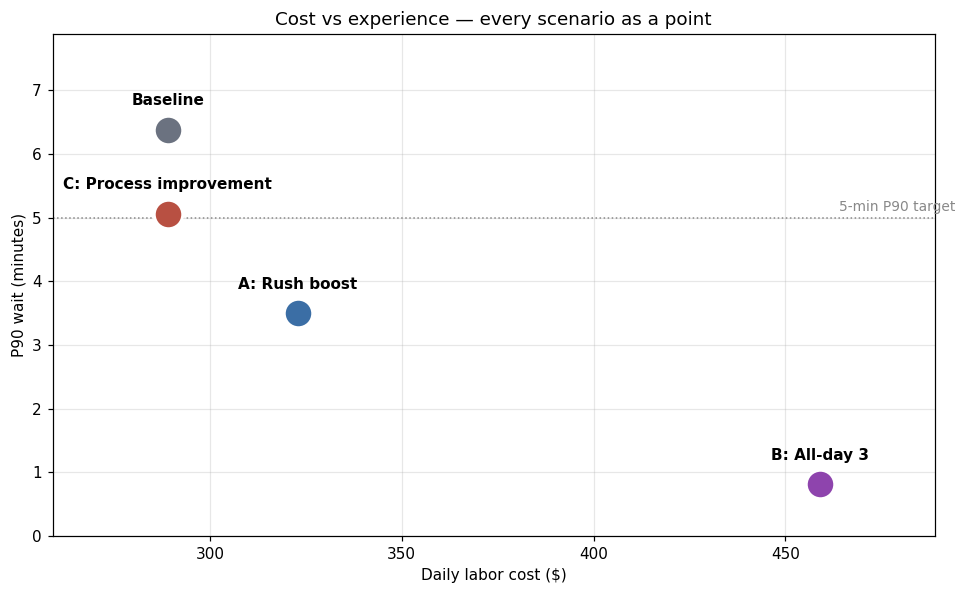

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for name, _ in sim.SCENARIOS.items():
    row = comparison.loc[name]
    ax.scatter(
        row["daily_cost_usd"], row["p90_wait_min"],
        s=350, color=SCENARIO_COLORS[name], edgecolor="white", linewidth=2, zorder=3,
        label=name,
    )
    ax.annotate(
        name,
        xy=(row["daily_cost_usd"], row["p90_wait_min"]),
        xytext=(0, 16), textcoords="offset points",
        ha="center", fontsize=10, fontweight="bold",
    )

ax.axhline(5, color="#888", linestyle=":", linewidth=1)
ax.text(comparison["daily_cost_usd"].max() + 5, 5.05, "5-min P90 target", color="#888", fontsize=9, va="bottom")

ax.set_xlabel("Daily labor cost ($)")
ax.set_ylabel("P90 wait (minutes)")
ax.set_title("Cost vs experience — every scenario as a point")
ax.set_xlim(comparison["daily_cost_usd"].min() - 30, comparison["daily_cost_usd"].max() + 30)
ax.set_ylim(0, comparison["p90_wait_min"].max() + 1.5)
plt.tight_layout()
plt.show()

The picture: B sits far down and to the right — best wait time, worst cost. A is at a clear sweet spot — about half the wait of baseline for a small bump in cost. C is in the middle on wait but tied with baseline on cost. The dotted line at five minutes is roughly what the owner's customers will tolerate without complaining; A and B are comfortably under it, C is just over.

## 4. Wait time CDFs — full distributions, not just headlines

A CDF answers "what fraction of customers wait *less than* X minutes." Read horizontally for "what's my P90?" and vertically for "what fraction wait under N minutes?"

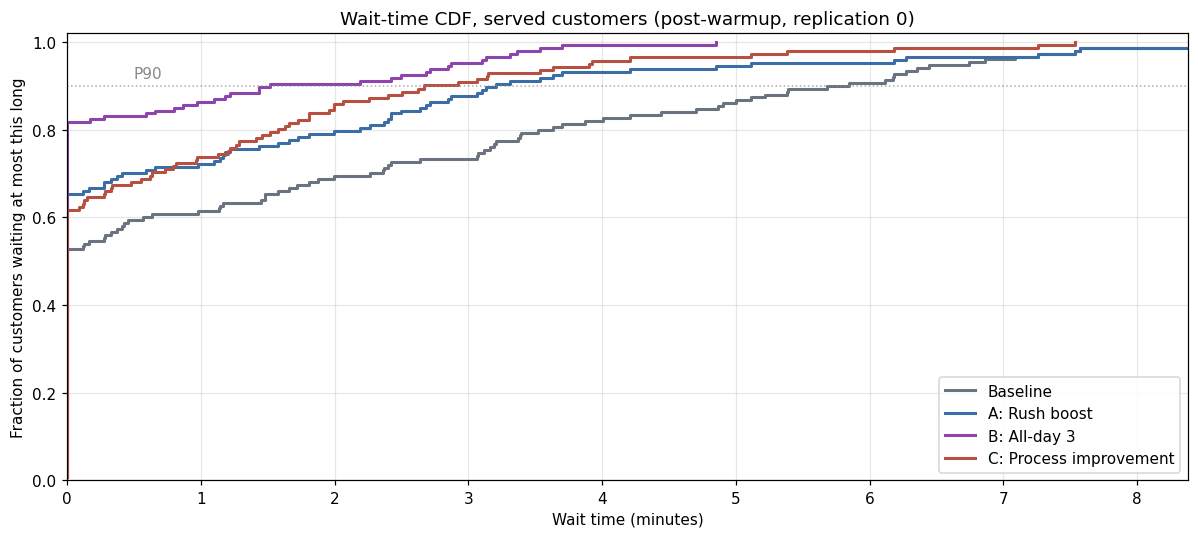

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

for name in sim.SCENARIOS:
    customers = all_customers[name]
    served = customers[(customers["outcome"] == "served") & (customers["arrival_time"] >= sim.WARMUP)]
    waits = np.sort(served["wait_time"].values)
    cdf = np.arange(1, len(waits) + 1) / len(waits)
    ax.step(waits, cdf, where="post", color=SCENARIO_COLORS[name], linewidth=2, label=name)

ax.axhline(0.90, color="#888", linestyle=":", linewidth=1, alpha=0.7)
ax.text(0.5, 0.91, "P90", fontsize=10, color="#888", va="bottom")

ax.set_xlabel("Wait time (minutes)")
ax.set_ylabel("Fraction of customers waiting at most this long")
ax.set_title("Wait-time CDF, served customers (post-warmup, replication 0)")
ax.set_xlim(0, max(8, comparison["p90_wait_min"].max() + 2))
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

The CDF tells the same story as the headline P90 number, but it tells the *full* story. Where a curve is steeper, more customers cluster around that wait. Where it's shallow, the wait distribution has a long tail.

Notice: B's CDF rockets up almost immediately — under three baristas all day, almost everyone is served instantly. A is close behind, with a slightly slower climb. C improves on baseline but trails A in the tail — the workflow speedup helps with most of the rush but not the worst-of-the-worst minutes.

## 5. Walkaway rates

Lower is better. The owner's original framing — "customers are walking out" — was the problem they articulated, even though it turned out to be smaller than the wait-time issue.

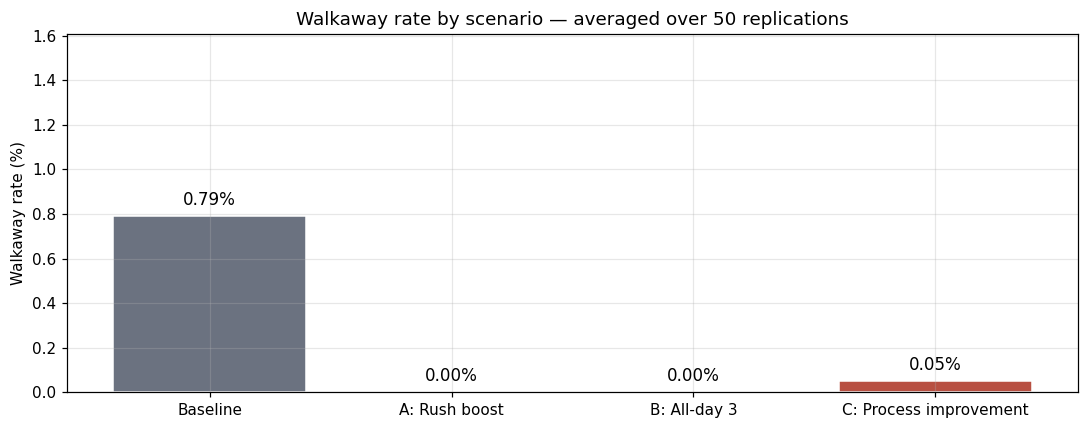

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

names = list(sim.SCENARIOS.keys())
walkaway_rates = [comparison.loc[n, "walkaway_rate_pct"] for n in names]
colors = [SCENARIO_COLORS[n] for n in names]

bars = ax.bar(names, walkaway_rates, color=colors, edgecolor="white")
for bar, rate in zip(bars, walkaway_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{rate:.2f}%", ha="center", fontsize=11)

ax.set_ylabel("Walkaway rate (%)")
ax.set_title("Walkaway rate by scenario — averaged over 50 replications")
ax.set_ylim(0, max(walkaway_rates) * 1.4 + 0.5)
plt.tight_layout()
plt.show()

Walkaways drop to roughly zero under both A and B. C reduces them but doesn't eliminate them — a 15% service-time reduction during the rush is enough to keep the queue under threshold most of the time, but not always.

## 6. Cost-effectiveness — minutes of P90 reduction per dollar

If we treat the baseline as the reference and ask "for each dollar of additional daily cost, how much P90-wait reduction do I get," the comparison sharpens further. Scenario C — zero additional cost — has undefined cost-effectiveness in this framing, so we treat it separately.

In [11]:
baseline_p90 = comparison.loc["Baseline", "p90_wait_min"]

cost_eff = []
for name in sim.SCENARIOS:
    if name == "Baseline":
        continue
    row = comparison.loc[name]
    p90_drop = baseline_p90 - row["p90_wait_min"]
    cost_delta = row["cost_delta_vs_baseline"]
    if cost_delta > 0:
        per_dollar = p90_drop / cost_delta * 60   # seconds-of-P90 saved per dollar
        cost_eff.append({
            "scenario": name,
            "p90_drop_min": round(p90_drop, 2),
            "cost_delta_usd": int(cost_delta),
            "seconds_saved_per_dollar": round(per_dollar, 2),
        })
    else:
        cost_eff.append({
            "scenario": name,
            "p90_drop_min": round(p90_drop, 2),
            "cost_delta_usd": int(cost_delta),
            "seconds_saved_per_dollar": float("inf"),
        })

cost_eff_df = pd.DataFrame(cost_eff).set_index("scenario")
print(cost_eff_df.to_string())

                        p90_drop_min  cost_delta_usd  seconds_saved_per_dollar
scenario                                                                      
A: Rush boost                   2.88              34                      5.08
B: All-day 3                    5.56             170                      1.96
C: Process improvement          1.32               0                       inf


Scenario C's cost delta is zero — it saves wait-time for free. That's not a small number on a per-dollar scale; it's a different category of intervention entirely.

Among the paid scenarios, A is meaningfully more cost-effective than B per dollar of P90 reduction: A's targeted two-hour rush boost gets the steep early gain, where the queue is most overloaded. B keeps adding capacity in windows where capacity wasn't the bottleneck — paying full labor cost for marginal returns.

## 7. The interesting comparison: A versus C

A adds labor for two hours. C changes the workflow during the rush. Both attack the same window. A produces a meaningfully shorter P90 wait than C — about three and a half minutes versus five — but the cost difference is the entire story: \$34/day for A versus zero for C. The question isn't *which one is better at reducing wait time* (A is, clearly) — the question is *which one is the right thing for the owner to try first*.

In [12]:
def section(label, value, unit=""):
    print(f"  {label:<32} {value}{unit}")

print("Scenario A: Rush boost")
print("=" * 50)
row_a = comparison.loc["A: Rush boost"]
section("Daily cost",          f"${row_a['daily_cost_usd']:.0f}")
section("P90 wait",             f"{row_a['p90_wait_min']:.2f}", " min")
section("Walkaway rate",        f"{row_a['walkaway_rate_pct']:.2f}", "%")
section("Morning utilization",  f"{row_a['morning_util']:.2f}")
print()
print("Scenario C: Process improvement")
print("=" * 50)
row_c = comparison.loc["C: Process improvement"]
section("Daily cost",          f"${row_c['daily_cost_usd']:.0f}")
section("P90 wait",             f"{row_c['p90_wait_min']:.2f}", " min")
section("Walkaway rate",        f"{row_c['walkaway_rate_pct']:.2f}", "%")
section("Morning utilization",  f"{row_c['morning_util']:.2f}")
print()
print("Annual cost difference (260 working days):")
annual_diff = (row_a["daily_cost_usd"] - row_c["daily_cost_usd"]) * 260
print(f"  ${annual_diff:,.0f}/year")

Scenario A: Rush boost
  Daily cost                       $323
  P90 wait                         3.50 min
  Walkaway rate                    0.00%
  Morning utilization              0.56

Scenario C: Process improvement
  Daily cost                       $289
  P90 wait                         5.06 min
  Walkaway rate                    0.05%
  Morning utilization              0.73

Annual cost difference (260 working days):
  $8,840/year


The trade-off is operational: C requires actually pulling off the workflow change. If the shop already has a dedicated order-taking position and pre-staged ingredients, the 15% rush-time service-time reduction is plausible. If the workflow change requires operational redesign that the team can't sustain, C is a paper number.

A is what you do if C doesn't stick. Or in addition to C, if C alone isn't enough — they don't conflict.

## 8. Your turn — write the recommendation

The simulation has produced four numbers per scenario across four scenarios. The hard work is no longer running models; it's translating numbers into a recommendation the owner can act on.

Write a 2-3 sentence recommendation in the cell below. Constraints:

- **No statistics jargon.** No "P90", no "standard error", no "utilization."
- **Connect to the decision.** The owner is choosing what to *do*, not what to *know*.
- **Acknowledge a trade-off explicitly.** Every recommendation has one.
- **Be falsifiable.** If your recommendation works, what would change? If it doesn't?

Read a few aloud. The differences in framing — risk-first, cost-first, customer-experience-first — show how the same simulation supports different defensible recommendations depending on what the decision-maker values most.

In [13]:
recommendation = """
TODO — write your 2-3 sentence recommendation to the shop owner here.

A useful template, if you want one:
  - What to try first, and why.
  - What to do if that doesn't work.
  - What you cannot tell them from this simulation alone.
"""

print(recommendation)


TODO — write your 2-3 sentence recommendation to the shop owner here.

A useful template, if you want one:
  - What to try first, and why.
  - What to do if that doesn't work.
  - What you cannot tell them from this simulation alone.



## What we leave the workshop with

Three things travel with you out of this room:

- A **spec-driven workflow** that connects data to distributions to a process spec to generated code to validation to a decision. The same A → B → C template structure applies to Monte Carlo, system dynamics, and agent-based models.
- A **library of LLM-assisted moves** for the modeling lifecycle. Code generation in Block 4. Spec-compliance review in Block 5. Logic review, test-scenario generation, stakeholder summaries, and assumption documentation in the bonus notebook. Each is a workflow, not a one-shot, and each ships with a saved-response fallback so you can study the pattern offline.
- A **skepticism reflex** about simulation metrics. The bug class that the spec-compliance review catches is the bug class that does *not* crash, does *not* produce weird numbers, and does *not* fail any obvious sanity check. The cheapest way to catch it is to read the code against the spec, with an LLM helping. The most expensive way is to ship the wrong recommendation and find out three months later.

Same loop, applied to the simulation problems on your own desk.

> *Data → distributions → spec → code → results → validation → decision.*

Good luck. Email me at dan@sullivanlearninggroup.com if you want to talk through how this applies to your specific work.